In [1]:
import pandas as pd
import numpy as np
import jieba
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 设置中文字体（Windows）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 加载清洗后的数据（如果之前已保存）
df = pd.read_csv('data/processed/cleaned_titles.csv')
print(df.shape)
df.head()

C:\Users\liuzi\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


(10000, 4)


,raw_text,cleaned_text,words,text_length
0,双十一就快到了，目前优惠活动现已出来了许多，那么多活动真实是让人看得目不暇接，目不暇接。不过...,双十一就快到了，目前优惠活动现已出来了许多，那么多活动真实是让人看得目不暇接，目不暇接。不过...,"['双十', '目前', '优惠活动', '现已', '出来', '许多', '那么', '...",50
1,不少妈咪都会遇到这样的问题，尤其是在哺乳期间，随时随地都要担心会不会有奶水流了下来，浸湿了衣...,不少妈咪都会遇到这样的问题，尤其是在哺乳期间，随时随地都要担心会不会有奶水流了下来，浸湿了衣...,"['不少', '妈咪', '遇到', '这样', '问题', '尤其', '哺乳', '期间...",50
2,茶水是中国最传统的饮品之一，同时饮茶也是中国的传统文化之一。不管是开心还是难过，不管是吵闹还...,茶水是中国最传统的饮品之一，同时饮茶也是中国的传统文化之一。不管是开心还是难过，不管是吵闹还...,"['茶水', '中国', '传统', '饮品', '之一', '同时', '饮茶', '中国...",50
3,氛围轻松、色调清新的北欧家装风格，总是给人的感觉非常轻松。用它来作为客厅空间的主角，即使简单...,氛围轻松、色调清新的北欧家装风格，总是给人的感觉非常轻松。用它来作为客厅空间的主角，即使简单...,"['氛围', '轻松', '色调', '清新', '北欧', '家装', '风格', '总是...",50
4,对于很多的家庭来说，卧室的装扮总是要多费一些心思的，毕竟是一天当中花费时间最多的地方。整个卧...,对于很多的家庭来说，卧室的装扮总是要多费一些心思的，毕竟是一天当中花费时间最多的地方。整个卧...,"['对于', '很多', '家庭', '来说', '卧室', '装扮', '总是', '多费...",50


标题长度统计：
count    10000.000000
mean        47.672700
std          7.558127
min          0.000000
25%         50.000000
50%         50.000000
75%         50.000000
max         50.000000
Name: length, dtype: float64


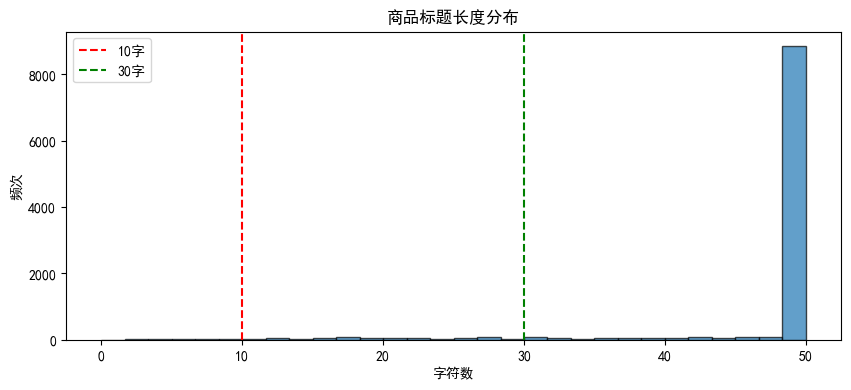

In [3]:
# 确保 cleaned_text 列是字符串类型，并将缺失值替换为空字符串
df['cleaned_text'] = df['cleaned_text'].fillna('').astype(str)

# 计算清洗后文本的长度
df['length'] = df['cleaned_text'].apply(len)

# 统计描述
print("标题长度统计：")
print(df['length'].describe())

# 绘制分布图
plt.figure(figsize=(10, 4))
plt.hist(df['length'], bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=10, color='red', linestyle='--', label='10字')
plt.axvline(x=30, color='green', linestyle='--', label='30字')
plt.legend()
plt.title('商品标题长度分布')
plt.xlabel('字符数')
plt.ylabel('频次')
plt.show()

In [4]:
# 示例品牌词（可根据实际情况扩充）
brand_words = ['华为', '小米', '苹果', 'OPPO', 'vivo', '三星', '荣耀', '耐克', '阿迪达斯', '李宁', '安踏', '优衣库', 'ZARA', 'H&M']

# 示例规格词
spec_words = ['手机', '内存', '容量', '颜色', '白色', '黑色', '红色', '蓝色', '尺寸', '型号', '版本', '新款', '包邮', '正品']

# 统计品牌词频次
brand_counts = {}
for word in brand_words:
    count = sum(word in words for words in df['words'])
    brand_counts[word] = count

# 统计规格词频次
spec_counts = {}
for word in spec_words:
    count = sum(word in words for words in df['words'])
    spec_counts[word] = count

# 输出 Top 品牌
print("品牌词出现频次（标题中包含该词的条数）：")
sorted_brand = sorted(brand_counts.items(), key=lambda x: x[1], reverse=True)
for word, cnt in sorted_brand:
    print(f"{word}: {cnt}")

print("\n规格词出现频次：")
sorted_spec = sorted(spec_counts.items(), key=lambda x: x[1], reverse=True)
for word, cnt in sorted_spec:
    print(f"{word}: {cnt}")

品牌词出现频次（标题中包含该词的条数）：
苹果: 28
华为: 14
小米: 12
荣耀: 10
三星: 8
OPPO: 4
耐克: 3
阿迪达斯: 3
vivo: 1
李宁: 1
安踏: 1
优衣库: 0
ZARA: 0
H&M: 0

规格词出现频次：
手机: 168
颜色: 126
白色: 53
黑色: 43
红色: 39
新款: 22
蓝色: 18
容量: 11
包邮: 10
尺寸: 6
内存: 5
型号: 2
正品: 1
版本: 0


In [5]:
# 假设原始文本还在 df['raw_text'] 中，如果没有，需要重新加载原始数据
# 若未保留，可重新读取原始文件
raw_texts = []
with open('data/content_tag_dataset.txt', 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 10000:
            break
        parts = line.strip().split('\t')
        if len(parts) >= 1 and parts[0]:
            raw_texts.append(parts[0])
df_raw = pd.DataFrame(raw_texts, columns=['raw_text'])

# 定义噪声检测函数
def classify_noise(text):
    # 表情符号：简单的范围匹配
    emoji_pattern = re.compile(r'[\U00010000-\U0010ffff]', flags=re.UNICODE)
    if emoji_pattern.search(text):
        return 'emoji'
    # 营销词（简单关键词）
    marketing_keywords = ['爆款', '热卖', '限量', '抢购', '特价', '秒杀', '正品保障', '假一赔十']
    if any(kw in text for kw in marketing_keywords):
        return 'marketing'
    # 错别字（可定义一些常见错别字模式，这里简单示例）
    typo_keywords = ['包邮', '包游', '保邮']  # 示例
    if any(kw in text for kw in typo_keywords):
        return 'typo'
    return 'normal'

df_raw['noise_type'] = df_raw['raw_text'].apply(classify_noise)

# 展示各类别的样例
print("=== 表情符号样例 ===")
print(df_raw[df_raw['noise_type'] == 'emoji']['raw_text'].head(3).values)

print("\n=== 营销词样例 ===")
print(df_raw[df_raw['noise_type'] == 'marketing']['raw_text'].head(3).values)

print("\n=== 错别字样例 ===")
print(df_raw[df_raw['noise_type'] == 'typo']['raw_text'].head(3).values)

# 也可以统计各类别占比
noise_counts = df_raw['noise_type'].value_counts()
print("\n噪声类型统计：")
print(noise_counts)

=== 表情符号样例 ===
[]

=== 营销词样例 ===
['秋冬在保暖的同时，穿出时髦和质感，也并不是那么简单。究竟要买什么单品呢？毫无头绪吗？快来跟小编看看，今年秋冬的热卖单品有哪些，让你驾驭任何风格毫无难度。'
 '双12热卖皮草这样穿最显瘦：皮草+羊毛衫+打底裤，澳洲进口美利奴羔羊毛+柔软羊皮/麂皮，内搭不需要臃肿，绒毛在内皮面在外，足够温暖，不臃肿的皮草够日常才实穿~'
 '大C家店铺商品全国包邮哦（偏远地区除外），我们是满200减20，不但上不封顶，而且可以跨店使用哦，快快来抢购哦！双12我们将继续加大优惠力度哦（满300减50，满400减70,满500减90）']

=== 错别字样例 ===
['【省钱日报】双十二土豆先生港风印花毛衣低至79元包邮，活动时间12月12日至12月13日。'
 '官方优惠5元无门槛优惠券，以及200-20、400-40优惠券以此类推上不封顶，以及店铺优惠券300-30、500-50等以此类优惠券，偏远地区外可包邮。活动时间12月12日零点到12月12日24点'
 '官方优惠5元无门槛优惠券，以及200-20、400-40优惠券以此类推上不封顶，以及店铺优惠券300-30、500-50等以此类优惠券，偏远地区外可包邮。活动时间12月12日零点到12月12日24点']

噪声类型统计：
noise_type
normal       9945
marketing      40
typo           15
Name: count, dtype: int64


In [6]:
# 准备一些示例文本
sample_texts = [
    "双十一购物狂欢节，全场包邮正品保障",
    "小米手机新款发布，8GB+256GB大内存",
    "这件衣服很显瘦，真的绝绝子"
]

# 原始分词（未加载自定义词典）
print("=== 原始分词效果 ===")
for text in sample_texts:
    words = jieba.lcut(text)
    print(f"{text} -> {words}")

# 创建自定义词典文件
custom_dict = "custom_dict.txt"
with open(custom_dict, 'w', encoding='utf-8') as f:
    f.write("双十一 100 n\n")
    f.write("包邮 100 n\n")
    f.write("绝绝子 100 n\n")
    f.write("显瘦 100 n\n")
    # 格式：词语 词频 词性（可选）

# 加载自定义词典
jieba.load_userdict(custom_dict)

print("\n=== 加载自定义词典后分词效果 ===")
for text in sample_texts:
    words = jieba.lcut(text)
    print(f"{text} -> {words}")

# 清除自定义词典，恢复原始状态（可选）
# jieba.del_word('双十一')  # 或者重新初始化

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\liuzi\AppData\Local\Temp\jieba.cache


=== 原始分词效果 ===


Loading model cost 0.607 seconds.
Prefix dict has been built successfully.


双十一购物狂欢节，全场包邮正品保障 -> ['双十', '一', '购物', '狂欢节', '，', '全场', '包邮', '正品', '保障']
小米手机新款发布，8GB+256GB大内存 -> ['小米', '手机', '新款', '发布', '，', '8GB', '+', '256GB', '大', '内存']
这件衣服很显瘦，真的绝绝子 -> ['这件', '衣服', '很显', '瘦', '，', '真的', '绝绝子']

=== 加载自定义词典后分词效果 ===
双十一购物狂欢节，全场包邮正品保障 -> ['双十一', '购物', '狂欢节', '，', '全场', '包邮', '正品', '保障']
小米手机新款发布，8GB+256GB大内存 -> ['小米', '手机', '新款', '发布', '，', '8GB', '+', '256GB', '大', '内存']
这件衣服很显瘦，真的绝绝子 -> ['这件', '衣服', '很', '显瘦', '，', '真的', '绝绝子']


1. 加载原始数据（前 10000 条）
成功加载 10000 条非空标题

2. 数据清洗
清洗完成

3. 分词与停用词过滤
分词完成

4. 短文本验证（长度分布）
标题长度统计：
count    10000.000000
mean        47.672700
std          7.558127
min          0.000000
25%         50.000000
50%         50.000000
75%         50.000000
max         50.000000
Name: length, dtype: float64


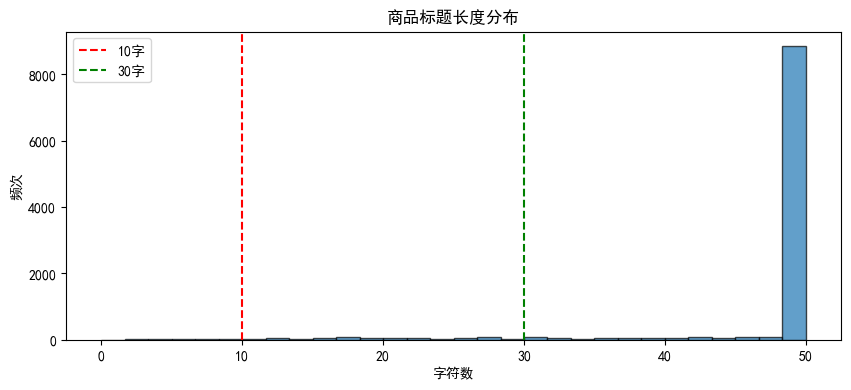

长度分布图已保存至 reports/length_distribution.png

5. 实体密集性分析（品牌词、规格词）


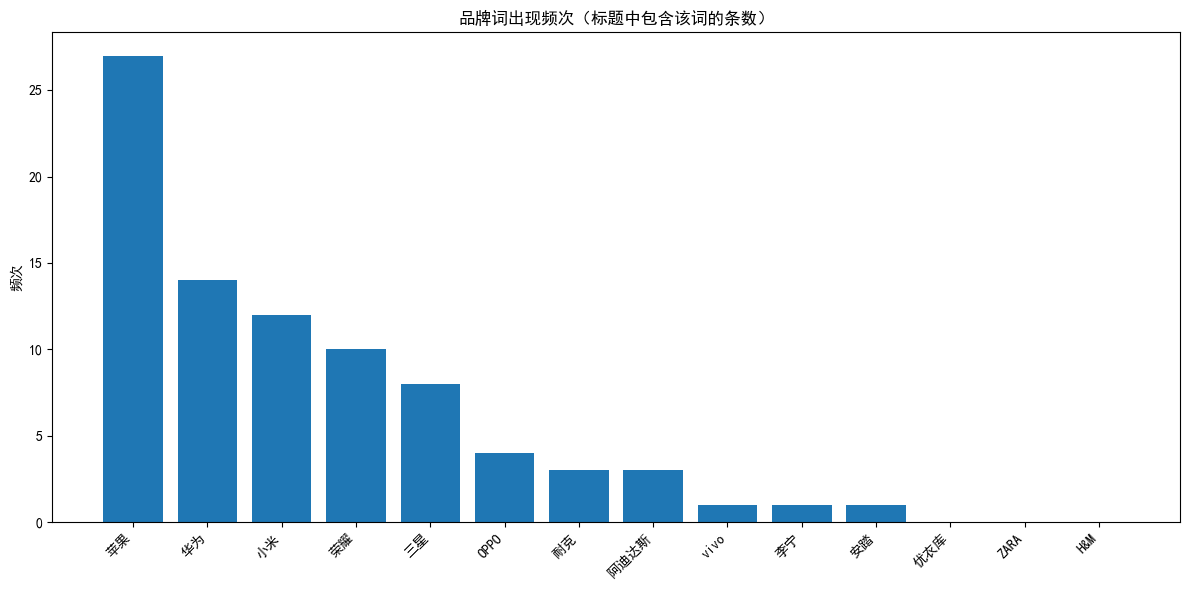

品牌词频次图已保存至 reports/brand_word_freq.png


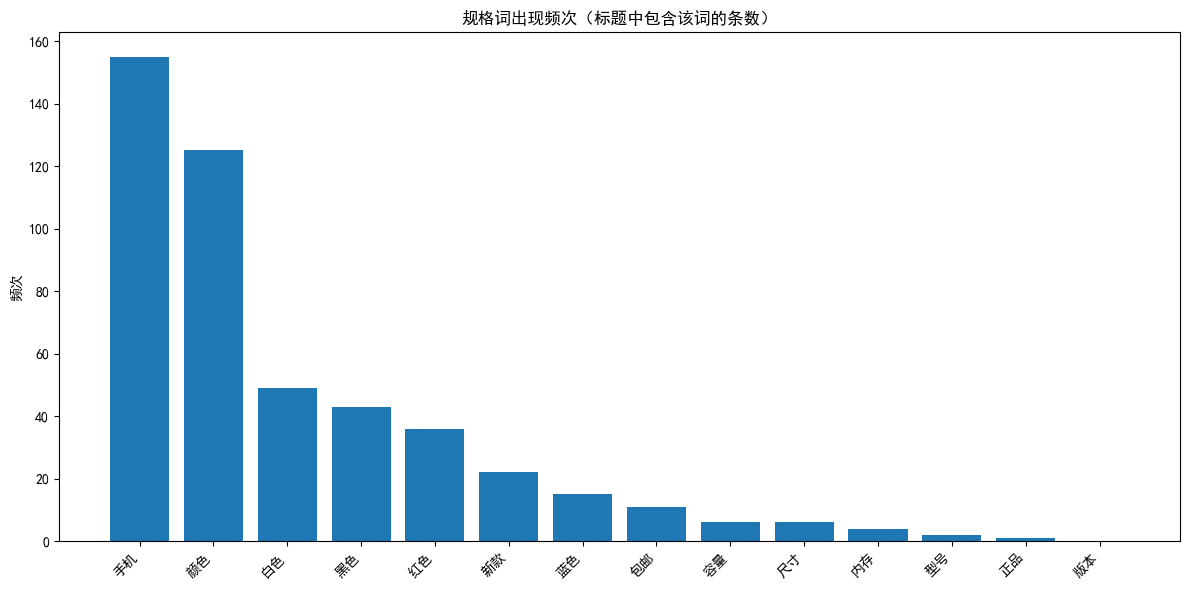

规格词频次图已保存至 reports/spec_word_freq.png

6. 口语化/噪声展示


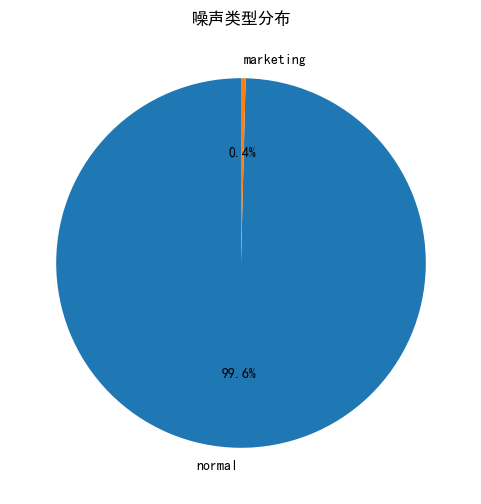

噪声分布图已保存至 reports/noise_type_pie.png

各类噪声样例：
表情符号样例： []
营销词样例： ['秋冬在保暖的同时，穿出时髦和质感，也并不是那么简单。究竟要买什么单品呢？毫无头绪吗？快来跟小编看看，今年秋冬的热卖单品有哪些，让你驾驭任何风格毫无难度。'
 '双12热卖皮草这样穿最显瘦：皮草+羊毛衫+打底裤，澳洲进口美利奴羔羊毛+柔软羊皮/麂皮，内搭不需要臃肿，绒毛在内皮面在外，足够温暖，不臃肿的皮草够日常才实穿~'
 '大C家店铺商品全国包邮哦（偏远地区除外），我们是满200减20，不但上不封顶，而且可以跨店使用哦，快快来抢购哦！双12我们将继续加大优惠力度哦（满300减50，满400减70,满500减90）']
错别字样例： []

7. 自定义词典效果对比
原始分词效果：
双十一购物狂欢节，全场包邮正品保障 -> ['双十一', '购物', '狂欢节', '，', '全场', '包邮', '正品', '保障']
小米手机新款发布，8GB+256GB大内存 -> ['小米', '手机', '新款', '发布', '，', '8GB', '+', '256GB', '大', '内存']
这件衣服很显瘦，真的绝绝子 -> ['这件', '衣服', '很', '显瘦', '，', '真的', '绝绝子']

加载自定义词典后分词效果：
双十一购物狂欢节，全场包邮正品保障 -> ['双十一', '购物', '狂欢节', '，', '全场', '包邮', '正品', '保障']
小米手机新款发布，8GB+256GB大内存 -> ['小米', '手机', '新款', '发布', '，', '8GB', '+', '256GB', '大', '内存']
这件衣服很显瘦，真的绝绝子 -> ['这件', '衣服', '很', '显瘦', '，', '真的', '绝绝子']

所有分析完成，图表已保存至 reports/ 文件夹。


In [7]:
import pandas as pd
import numpy as np
import jieba
import matplotlib.pyplot as plt
import re
import os
from collections import Counter

# 设置中文字体（Windows）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 创建 reports 文件夹
os.makedirs('reports', exist_ok=True)

print("=" * 50)
print("1. 加载原始数据（前 10000 条）")
print("=" * 50)

# 从原始文件提取前 10000 条文本
texts = []
with open('data/content_tag_dataset.txt', 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 10000:
            break
        parts = line.strip().split('\t')
        if len(parts) >= 1 and parts[0]:
            texts.append(parts[0])
        else:
            texts.append('')   # 避免空值

df = pd.DataFrame(texts, columns=['raw_text'])
# 删除空文本行
df = df[df['raw_text'] != ''].reset_index(drop=True)
print(f"成功加载 {len(df)} 条非空标题")

print("\n" + "=" * 50)
print("2. 数据清洗")
print("=" * 50)

def clean_text(text):
    # 去除特殊符号（保留中文、英文、数字、常用中文标点）
    text = re.sub(r'[^\u4e00-\u9fa5a-zA-Z0-9，。！？、；：“”‘’（）【】《》]', ' ', text)
    # 合并连续空格
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    # 长度截断
    if len(text) > 50:
        text = text[:50]
    return text

df['cleaned_text'] = df['raw_text'].apply(clean_text)
print("清洗完成")

print("\n" + "=" * 50)
print("3. 分词与停用词过滤")
print("=" * 50)

# 简单停用词表
stopwords = set([
    '的', '了', '在', '是', '我', '有', '和', '就', '不', '人', '都', '一', '一个',
    '上', '也', '很', '到', '说', '要', '去', '你', '会', '着', '没有', '看', '好',
    '自己', '这', '那', '吗', '吧', '啊', '哦', '嗯', '我们', '可以', '就是', '因为',
    '所以', '但是', '如果', '什么', '怎么', '这么', '这个', '那个', '这些', '那些',
    '然后', '之后', '以上', '以下', '你们', '他们', '她', '他', '它'
])

def segment(text):
    words = jieba.lcut(text)
    words = [w for w in words if w not in stopwords and len(w) > 1]
    return words

df['words'] = df['cleaned_text'].apply(segment)
print("分词完成")

print("\n" + "=" * 50)
print("4. 短文本验证（长度分布）")
print("=" * 50)

# 确保 cleaned_text 为字符串（处理可能的 NaN）
df['cleaned_text'] = df['cleaned_text'].fillna('').astype(str)
df['length'] = df['cleaned_text'].apply(len)

print("标题长度统计：")
print(df['length'].describe())

plt.figure(figsize=(10, 4))
plt.hist(df['length'], bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=10, color='red', linestyle='--', label='10字')
plt.axvline(x=30, color='green', linestyle='--', label='30字')
plt.legend()
plt.title('商品标题长度分布')
plt.xlabel('字符数')
plt.ylabel('频次')
plt.savefig('reports/length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("长度分布图已保存至 reports/length_distribution.png")

print("\n" + "=" * 50)
print("5. 实体密集性分析（品牌词、规格词）")
print("=" * 50)

# 品牌词列表（可自行扩充）
brand_words = ['华为', '小米', '苹果', 'OPPO', 'vivo', '三星', '荣耀', '耐克', '阿迪达斯', '李宁', '安踏', '优衣库', 'ZARA', 'H&M']
# 规格词列表
spec_words = ['手机', '内存', '容量', '颜色', '白色', '黑色', '红色', '蓝色', '尺寸', '型号', '版本', '新款', '包邮', '正品']

brand_counts = {w: sum(w in words for words in df['words']) for w in brand_words}
spec_counts = {w: sum(w in words for words in df['words']) for w in spec_words}

# 绘制品牌词频次图
plt.figure(figsize=(12, 6))
sorted_brand = sorted(brand_counts.items(), key=lambda x: x[1], reverse=True)
names, values = zip(*sorted_brand)
plt.bar(names, values)
plt.xticks(rotation=45, ha='right')
plt.title('品牌词出现频次（标题中包含该词的条数）')
plt.ylabel('频次')
plt.tight_layout()
plt.savefig('reports/brand_word_freq.png', dpi=150)
plt.show()
print("品牌词频次图已保存至 reports/brand_word_freq.png")

# 绘制规格词频次图
plt.figure(figsize=(12, 6))
sorted_spec = sorted(spec_counts.items(), key=lambda x: x[1], reverse=True)
names, values = zip(*sorted_spec)
plt.bar(names, values)
plt.xticks(rotation=45, ha='right')
plt.title('规格词出现频次（标题中包含该词的条数）')
plt.ylabel('频次')
plt.tight_layout()
plt.savefig('reports/spec_word_freq.png', dpi=150)
plt.show()
print("规格词频次图已保存至 reports/spec_word_freq.png")

print("\n" + "=" * 50)
print("6. 口语化/噪声展示")
print("=" * 50)

def classify_noise(text):
    # 表情符号
    emoji_pattern = re.compile(r'[\U00010000-\U0010ffff]', flags=re.UNICODE)
    if emoji_pattern.search(text):
        return 'emoji'
    # 营销词
    marketing_keywords = ['爆款', '热卖', '限量', '抢购', '特价', '秒杀', '正品保障', '假一赔十']
    if any(kw in text for kw in marketing_keywords):
        return 'marketing'
    # 错别字（示例）
    typo_keywords = ['包游', '保邮', '苹国', '华威']
    if any(kw in text for kw in typo_keywords):
        return 'typo'
    return 'normal'

df['noise_type'] = df['raw_text'].apply(classify_noise)
noise_counts = df['noise_type'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(noise_counts.values, labels=noise_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('噪声类型分布')
plt.savefig('reports/noise_type_pie.png', dpi=150)
plt.show()
print("噪声分布图已保存至 reports/noise_type_pie.png")

print("\n各类噪声样例：")
print("表情符号样例：", df[df['noise_type'] == 'emoji']['raw_text'].head(3).values)
print("营销词样例：", df[df['noise_type'] == 'marketing']['raw_text'].head(3).values)
print("错别字样例：", df[df['noise_type'] == 'typo']['raw_text'].head(3).values)

print("\n" + "=" * 50)
print("7. 自定义词典效果对比")
print("=" * 50)

sample_texts = [
    "双十一购物狂欢节，全场包邮正品保障",
    "小米手机新款发布，8GB+256GB大内存",
    "这件衣服很显瘦，真的绝绝子"
]

print("原始分词效果：")
for text in sample_texts:
    words = jieba.lcut(text)
    print(f"{text} -> {words}")

# 创建自定义词典
with open('custom_dict.txt', 'w', encoding='utf-8') as f:
    f.write("双十一 100 n\n")
    f.write("包邮 100 n\n")
    f.write("绝绝子 100 n\n")
    f.write("显瘦 100 n\n")

jieba.load_userdict('custom_dict.txt')
print("\n加载自定义词典后分词效果：")
for text in sample_texts:
    words = jieba.lcut(text)
    print(f"{text} -> {words}")

print("\n所有分析完成，图表已保存至 reports/ 文件夹。")